# ⚠️ KEEP-W12 VARIANT — generated copy, do not edit by hand
Generated from `speed_dating_eda_data_cleaning.ipynb` (2026-06-12) with **exactly four changes**:
1. Step **B1 (drop wave 12) is skipped** — wave 12's 392 rows are retained.
2. Final sanity assertions updated: 7,976 rows / 20 waves / 523 participants → **8,368 / 21 / 551**.
3. Outputs renamed and relocated: **`speed_dating_clean_keep_w12.csv/.parquet` in the project root** (the canonical `kaggle_upload/` artifacts are never touched).
4. Kaggle upload cells disabled.

Every cleaning transform is byte-identical to the original (all transforms are row-local — none fits statistics on the dataset, so skipping the drop cannot change other waves' values). The final cell cross-checks this: *this dataset minus wave 12 must equal the canonical parquet exactly.*

Regenerate after any change to the original: the build script lives in the session notes; or simply re-apply the four changes above.

# Speed Dating — EDA & Data Cleaning (CS608)

Columbia Business School Speed Dating Experiment (Fisman & Iyengar, 2002–2004).

This notebook produces `speed_dating_clean.csv`, `speed_dating_clean.parquet`, `column_roles.json`, and `DATA_DICTIONARY.md` for the modeling stage. See `EDA_and_Cleaning_Walkthrough.md` for the full narrative.

## Setup

Imports and display options used throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
sns.set_theme(style='whitegrid')

RANDOM_SEED = 42

## Part 0 — Loading the Data

Read the raw CSV with `cp1252` encoding (Windows Latin-1). The first column has a blank header in the file; pandas labels it `Unnamed: 0` — we rename it to `iid`.

In [2]:
RAW_PATH = 'Speed Dating Data.csv'

df_raw = pd.read_csv(RAW_PATH, encoding='cp1252')

# The first column ships with a blank header (file starts with ",id,gender,...")
# so pandas labels it "Unnamed: 0"; it actually holds the participant id (iid).
df_raw = df_raw.rename(columns={df_raw.columns[0]: 'iid'})

print('Shape:', df_raw.shape)
print('Unique participants (iid):', df_raw['iid'].nunique())
print('Unique waves:', df_raw['wave'].nunique())
df_raw.head()

Shape: (8378, 195)
Unique participants (iid): 551
Unique waves: 21


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,...,amb1_3,shar1_3,attr7_3,sinc7_3,intel7_3,fun7_3,amb7_3,shar7_3,attr4_3,sinc4_3,intel4_3,fun4_3,amb4_3,shar4_3,attr2_3,sinc2_3,intel2_3,fun2_3,amb2_3,shar2_3,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.000,0,1,1,1,10,7,NaN,4,1,11.000,0,0.140,0,27.000,2.000,35.000,20.000,20.000,20.000,0.000,5.000,0,6.000,8.000,8.000,8.000,8.000,6.000,...,15.000,15.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000,7.000,7.000,7.000,7.000,NaN,NaN,NaN,NaN,NaN
1,1,1.000,0,1,1,1,10,7,NaN,3,2,12.000,0,0.540,0,22.000,2.000,60.000,0.000,0.000,40.000,0.000,0.000,0,7.000,8.000,10.000,7.000,7.000,5.000,...,15.000,15.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000,7.000,7.000,7.000,7.000,NaN,NaN,NaN,NaN,NaN
2,1,1.000,0,1,1,1,10,7,NaN,10,3,13.000,1,0.160,1,22.000,4.000,19.000,18.000,19.000,18.000,14.000,12.000,1,10.000,10.000,10.000,10.000,10.000,10.000,...,15.000,15.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000,7.000,7.000,7.000,7.000,NaN,NaN,NaN,NaN,NaN
3,1,1.000,0,1,1,1,10,7,NaN,5,4,14.000,1,0.610,0,23.000,2.000,30.000,5.000,15.000,40.000,5.000,5.000,1,7.000,8.000,9.000,8.000,9.000,8.000,...,15.000,15.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000,7.000,7.000,7.000,7.000,NaN,NaN,NaN,NaN,NaN
4,1,1.000,0,1,1,1,10,7,NaN,7,5,15.000,1,0.210,0,24.000,3.000,30.000,10.000,20.000,10.000,10.000,20.000,1,8.000,7.000,9.000,6.000,9.000,7.000,...,15.000,15.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000,7.000,7.000,7.000,7.000,NaN,NaN,NaN,NaN,NaN


# Part A — Exploratory Data Analysis

All EDA below runs on **df_raw** before any cleaning.

In [3]:
print('Dtype counts:')
print(df_raw.dtypes.value_counts())

print('\nObject (string) columns:')
print(df_raw.select_dtypes('object').columns.tolist())

# A row = one person's rating of one partner in one date. It is directional.
print('\nRows:', len(df_raw))
print('Approx. directed pairs (rows with a partner id):', df_raw['pid'].notna().sum())

Dtype counts:
float64    174
int64       13
object       8
Name: count, dtype: int64

Object (string) columns:
['field', 'undergra', 'mn_sat', 'tuition', 'from', 'zipcode', 'income', 'career']

Rows: 8378
Approx. directed pairs (rows with a partner id): 8368


Top 30 most-missing columns:
num_in_3   92.000
numdat_3   82.100
expnum     78.500
sinc7_2    76.700
amb7_2     76.700
shar7_2    76.400
attr7_2    76.300
intel7_2   76.300
fun7_2     76.300
amb5_3     75.900
attr7_3    75.900
sinc7_3    75.900
intel7_3   75.900
fun7_3     75.900
amb7_3     75.900
shar7_3    75.900
shar2_3    75.900
attr5_3    75.900
sinc5_3    75.900
intel5_3   75.900
fun5_3     75.900
attr4_3    64.700
sinc4_3    64.700
intel4_3   64.700
fun4_3     64.700
amb4_3     64.700
shar4_3    64.700
attr2_3    64.700
sinc2_3    64.700
fun2_3     64.700
dtype: float64


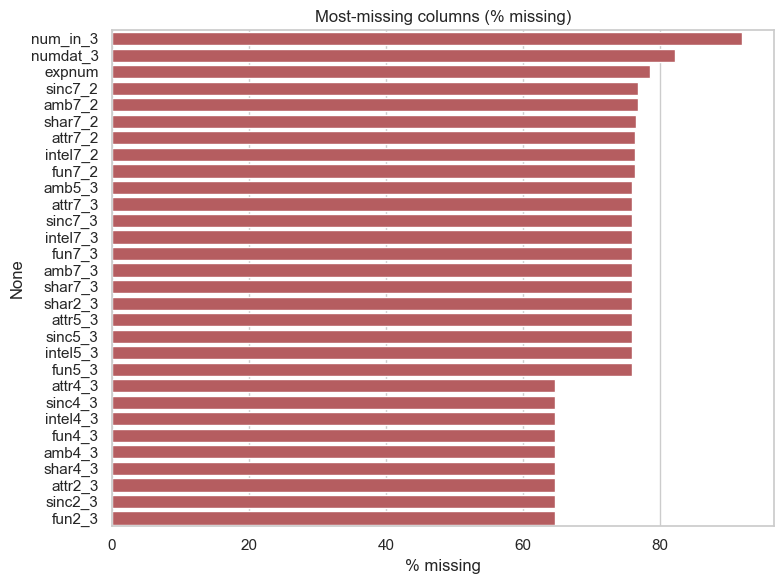

In [4]:
miss = (df_raw.isna().mean() * 100).sort_values(ascending=False).round(1)
print('Top 30 most-missing columns:')
print(miss.head(30))

plt.figure(figsize=(8, 6))
sns.barplot(x=miss.head(30).values, y=miss.head(30).index, color='#C44E52')
plt.title('Most-missing columns (% missing)')
plt.xlabel('% missing'); plt.tight_layout(); plt.show()

Missingness decides what we keep. We find a clean three-tier structure: core columns (IDs, outcomes, demographics) are <2% missing; a middle tier is structurally missing (collected only in some waves.

      interactions  n_participants  match_rate  dec_rate
wave                                                    
1              200              20       0.310     0.555
2              608              35       0.102     0.373
3              200              20       0.130     0.335
4              648              36       0.201     0.429
5              190              19       0.284     0.500
6               50              10       0.200     0.500
7              512              32       0.168     0.430
8              200              20       0.180     0.430
9              800              40       0.155     0.430
10             162              18       0.185     0.488
11             882              42       0.145     0.404
12             392              28       0.107     0.339
13             180              19       0.178     0.478
14             720              38       0.175     0.422
15             684              37       0.184     0.452
16              96             

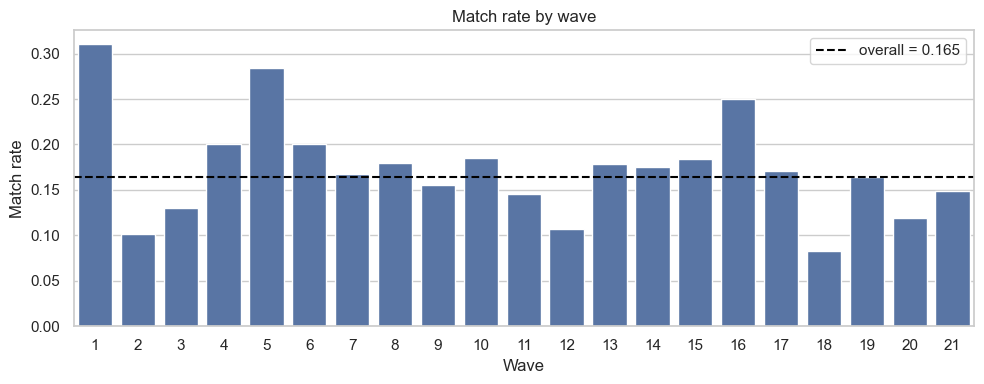

In [5]:
wave_summary = (
    df_raw.groupby('wave')
    .agg(
        interactions=('iid', 'size'),
        n_participants=('iid', 'nunique'),
        match_rate=('match', 'mean'),
        dec_rate=('dec', 'mean'),
    )
    .round(3)
)
print(wave_summary)

plt.figure(figsize=(10, 4))
sns.barplot(x=wave_summary.index, y=wave_summary['match_rate'], color='#4C72B0')
plt.axhline(df_raw['match'].mean(), ls='--', color='black',
            label=f"overall = {df_raw['match'].mean():.3f}")
plt.title('Match rate by wave')
plt.xlabel('Wave'); plt.ylabel('Match rate'); plt.legend()
plt.tight_layout(); plt.show()

Match rate varies enormously across the 21 events (we will see roughly 8% to 31%). That variation is a structural fact, not noise, and it drives two later decisions: (1) train/test splits must be wave-based, never row-based, or the model leaks; and (2) the experiment's two conditions and the budget-constrained Wave 12 must be handled.

In [6]:
for col in ['dec', 'dec_o', 'match']:
    print(f'P({col}=1) = {df_raw[col].mean():.4f}')

# Is match exactly dec & dec_o?
recomputed = ((df_raw['dec'] == 1) & (df_raw['dec_o'] == 1)).astype(int)
print('\nmatch inconsistencies vs (dec & dec_o):', (recomputed != df_raw['match']).sum())  # expect 0

print('\nDecision rate by gender (0 = Female, 1 = Male):')
print(df_raw.groupby('gender')['dec'].mean().round(3))

P(dec=1) = 0.4199
P(dec_o=1) = 0.4196
P(match=1) = 0.1647

match inconsistencies vs (dec & dec_o): 0

Decision rate by gender (0 = Female, 1 = Male):
gender
0   0.365
1   0.474
Name: dec, dtype: float64


In [7]:
clean_for_corr = df_raw[(df_raw['wave'] != 12) & (df_raw['pid'].notna())]

r = clean_for_corr[['dec', 'dec_o']].corr().iloc[0, 1]
p_dec = clean_for_corr['dec'].mean()
p_dec_o = clean_for_corr['dec_o'].mean()
expected_if_independent = p_dec * p_dec_o
observed_match = clean_for_corr['match'].mean()

print(f'Pearson(dec, dec_o)        = {r:+.4f}')
print(f'Expected match if indep.   = {expected_if_independent:.4f}')
print(f'Observed match rate        = {observed_match:.4f}')

Pearson(dec, dec_o)        = -0.0493
Expected match if indep.   = 0.1798
Observed match rate        = 0.1678


Top-quintile mean yes-rate received   : 0.778
Bottom-quintile mean yes-rate received: 0.12
Corr(mean attr received, yes-rate received): 0.797


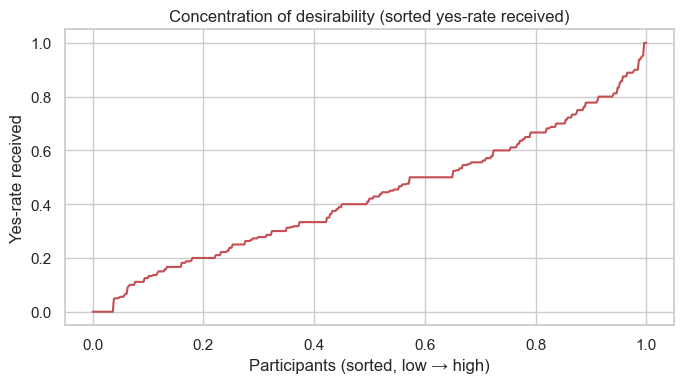

In [8]:
# Per-person desirability, computed from the partner's decision recorded on each row.
desirability = (
    clean_for_corr.groupby('iid')
    .agg(yes_rate_received=('dec_o', 'mean'),
         mean_attr_received=('attr_o', 'mean'))
)

top_q = desirability['yes_rate_received'].quantile(0.8)
bot_q = desirability['yes_rate_received'].quantile(0.2)
print('Top-quintile mean yes-rate received   :',
      round(desirability.loc[desirability['yes_rate_received'] >= top_q, 'yes_rate_received'].mean(), 3))
print('Bottom-quintile mean yes-rate received:',
      round(desirability.loc[desirability['yes_rate_received'] <= bot_q, 'yes_rate_received'].mean(), 3))
print('Corr(mean attr received, yes-rate received):',
      round(desirability['yes_rate_received'].corr(desirability['mean_attr_received']), 3))

plt.figure(figsize=(7, 4))
sorted_vals = desirability['yes_rate_received'].sort_values().values
plt.plot(np.linspace(0, 1, len(sorted_vals)), sorted_vals, color='#C44E52')
plt.title('Concentration of desirability (sorted yes-rate received)')
plt.xlabel('Participants (sorted, low → high)'); plt.ylabel('Yes-rate received')
plt.tight_layout(); plt.show()

like    0.515
attr    0.488
fun     0.414
shar    0.403
prob    0.312
intel   0.215
sinc    0.209
amb     0.184
Name: dec, dtype: float64


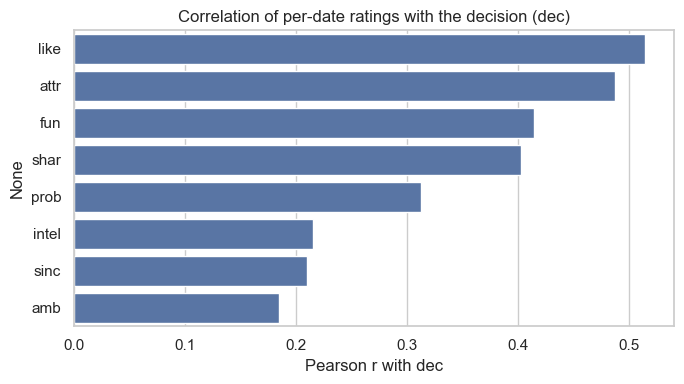

In [9]:
rate_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']
corrs = (clean_for_corr[rate_cols + ['dec']]
         .corr()['dec'].drop('dec').sort_values(ascending=False))
print(corrs.round(3))

plt.figure(figsize=(7, 4))
sns.barplot(x=corrs.values, y=corrs.index, color='#4C72B0')
plt.title('Correlation of per-date ratings with the decision (dec)')
plt.xlabel('Pearson r with dec'); plt.tight_layout(); plt.show()

          mean  pct_ge_9  pct_eq_10
attr3_1  7.090    11.980      3.090
sinc3_1  8.290    48.460     19.960
intel3_1 8.390    46.100     15.060
fun3_1   7.700    31.760     10.530
amb3_1   7.580    32.490     13.250


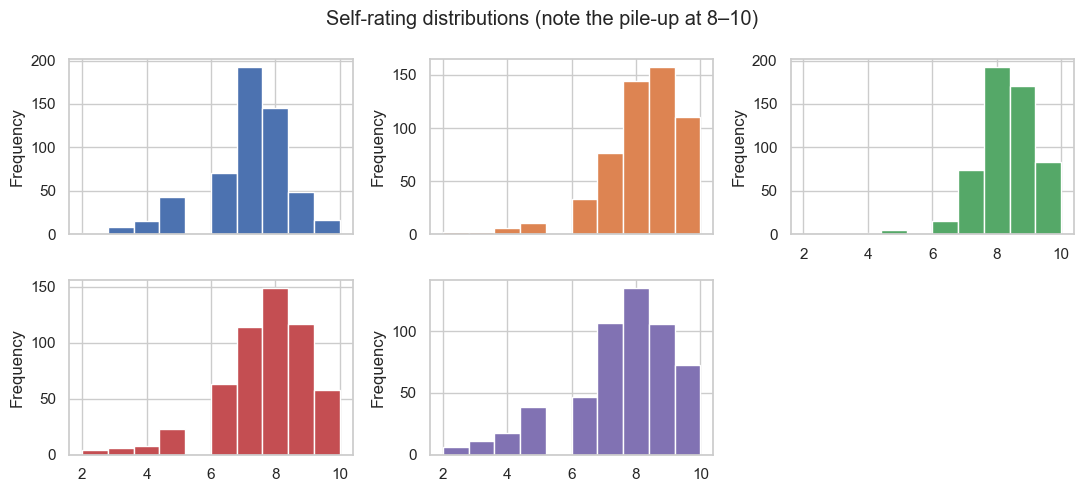

In [10]:
self_cols = ['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']
person_lvl = df_raw.drop_duplicates('iid')

ceiling = pd.DataFrame({
    'mean': person_lvl[self_cols].mean(),
    'pct_ge_9': (person_lvl[self_cols] >= 9).mean() * 100,
    'pct_eq_10': (person_lvl[self_cols] == 10).mean() * 100,
}).round(2)
print(ceiling)

person_lvl[self_cols].plot(kind='hist', bins=10, subplots=True, layout=(2, 3),
                           figsize=(11, 5), legend=False, sharex=True)
plt.suptitle('Self-rating distributions (note the pile-up at 8–10)')
plt.tight_layout(); plt.show()

Self-ratings are available at signup (so they are legal features), but they are badly affected by social-desirability bias. We find that nearly half of all participants rate their own sincerity and intelligence ≥9 — the scale is jammed at the top. A variable where everyone gives nearly the same answer carries almost no information, which is why self-rated sincerity/intelligence correlate near zero with how others actually rate them. This is the evidence base for the cleaning decision to z-score self-ratings within gender

In [11]:
scale_1_10_waves = [6, 7, 8, 9]
is_1_10 = df_raw['wave'].isin(scale_1_10_waves)

print('Participants on 1-10 scale (waves 6-9):',
      df_raw.loc[is_1_10, 'iid'].nunique())
print('Participants on 100-pt scale (other waves):',
      df_raw.loc[~is_1_10, 'iid'].nunique())

pref_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
alloc_people = df_raw.drop_duplicates('iid')
alloc_people = alloc_people[~alloc_people['wave'].isin(scale_1_10_waves)]
sums = alloc_people[pref_cols].sum(axis=1, min_count=6).dropna()

print('\n100-pt waves: signup preference sums')
print('  sum exactly 100      :', int((sums == 100).sum()))
print('  sum within [95, 105] :', int(((sums >= 95) & (sums <= 105)).sum()))
print('  sum outside [95, 105]:', int(((sums < 95) | (sums > 105)).sum()))
print('  example bad sums     :', sorted(sums[(sums < 95) | (sums > 105)].unique())[:8])

Participants on 1-10 scale (waves 6-9): 102
Participants on 100-pt scale (other waves): 449

100-pt waves: signup preference sums
  sum exactly 100      : 424
  sum within [95, 105] : 432
  sum outside [95, 105]: 8
  example bad sums     : [np.float64(90.0), np.float64(110.0), np.float64(120.0), np.float64(148.0)]


In [12]:
tmp = clean_for_corr.copy()
tmp['age_diff'] = (tmp['age'] - tmp['age_o']).abs()
bins = [-0.1, 0.5, 2, 5, 10, 100]
labels = ['0', '1-2', '3-5', '6-10', '11+']
tmp['age_gap_band'] = pd.cut(tmp['age_diff'], bins=bins, labels=labels)

print('Match rate by age gap:')
print(tmp.groupby('age_gap_band', observed=True)['match'].mean().round(3))

print('\nSame race (1) vs different (0):')
print('  match rate:', tmp.groupby('samerace')['match'].mean().round(3).to_dict())
print('  dec rate  :', tmp.groupby('samerace')['dec'].mean().round(3).to_dict())

Match rate by age gap:
age_gap_band
0      0.208
1-2    0.187
3-5    0.160
6-10   0.136
11+    0.087
Name: match, dtype: float64

Same race (1) vs different (0):
  match rate: {0: 0.163, 1: 0.175}
  dec rate  : {0: 0.413, 1: 0.441}


This tells us which pair-level features are worth engineering. Age gap shows a clean monotonic signal — match rate falls from ~20% (same age) to ~9% (11+ years apart) — so age_diff is a genuinely useful feature we will derive

# Part B — Data Cleaning

Anything that needs a statistic computed across rows — imputing with a column mean, z-scoring with a group mean/SD — is deferred to the modeling pipeline, because those statistics must be fit on the training fold only. If we computed them here on the full dataset, information from the test fold would leak into training.

Never turn an outcome into a feature. The per-date ratings (attr, like, …) and their _o mirrors describe what happened during the date. They are kept in the cleaned file but cannot be used as features.

In [13]:
df = df_raw.copy()
print('Starting rows:', len(df))

Starting rows: 8378


### Drop Wave 12 — **SKIPPED in this keep-w12 variant**
Wave 12 ran under an explicit budget rule: participants were only allowed to say "yes" to at most 50% of their partners. That artificially suppresses both the decision rate and the match rate for reasons that have nothing to do with attraction.

**This variant keeps wave 12 on purpose** so the splitting-scheme study (S1/S3/S5/S7/S9) can measure exactly how much that corruption costs. The canonical dataset still drops it.

In [14]:
# B1 — Drop Wave 12: SKIPPED in this keep-w12 variant.
# (Original line: df = df[df['wave'] != 12].copy())
print(f"Wave 12 KEPT: {(df['wave'] == 12).sum()} rows retained (expected 392).")

Wave 12 KEPT: 392 rows retained (expected 392).


### Drop null-pid rows
We investigated these rows: all 10 are in Wave 5 (10 men, 9 women, round size 10), and every one is a female participant (gender = 1) with partner = 7 and a null pid. Here partner is the badge number on the scorecard column, not "the 7th woman out of 9." Each woman is filling in the slot for Man #7, but Wave 5 has no male with event id = 7: the men's badge IDs are 1, 2, 3, 4, 5, 6, 10, 11, 12 (gaps at 7–9). The number 7 does appear in the wave — it belongs to a woman (iid 128), which is why men dating partner = 7 resolve cleanly to pid = 128, while women dating partner = 7 cannot resolve any pid. 

In [15]:
before = len(df)
df = df[df['pid'].notna()].copy()
print(f'Dropped null-pid rows: {before - len(df)} rows removed (expected 10).')
print('Rows now:', len(df), '| participants:', df['iid'].nunique(), '| waves:', df['wave'].nunique())
# Expected (keep-w12 variant): 8368 rows, 551 participants, 21 waves.

Dropped null-pid rows: 10 rows removed (expected 10).
Rows now: 8368 | participants: 551 | waves: 21


### Zeros → NaN in rating columns

All per-date ratings are on a **1–10** scale, so `0` is out of range. It is the data-entry convention for "did not rate / no opinion," not a genuine score of zero. If we leave zeros in, they behave like an extremely harsh rating and distort every mean, correlation, and model that touches these columns — most severely for `shar` and `prob`. Converting to `NaN` lets the (deferred) imputation step treat them as missing rather than as false data.

In [16]:
rating_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob',
               'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o']

zeros_before = (df[rating_cols] == 0).sum().sum()
df[rating_cols] = df[rating_cols].replace(0, np.nan)
print(f'Replaced {zeros_before} zero-ratings with NaN across {len(rating_cols)} columns.')

Replaced 314 zero-ratings with NaN across 16 columns.


### Cap out-of-range ratings

The rating scale tops out at 10, so values above 10 are entry errors (e.g. `10.5` in `attr_o`, `11.0` in `fun_o`). Clipping them down to 10 is the least-assumption fix. `NaN` values are left untouched by `clip`.

In [17]:
over_before = (df[rating_cols] > 10).sum().sum()
df[rating_cols] = df[rating_cols].clip(upper=10)
print(f'Clipped {over_before} out-of-range (>10) ratings down to 10 (expected 2).')

Clipped 2 out-of-range (>10) ratings down to 10 (expected 2).


### Cap out-of-range interest values
Interests are also on a 1–10 scale. The out-of-range values come from a small number of people — 5 participants entered gaming = 14 and 3 entered reading = 13

In [18]:
interest_cols = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking',
                 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts',
                 'music', 'shopping', 'yoga']

over_before = (df[interest_cols] > 10).sum().sum()
df[interest_cols] = df[interest_cols].clip(upper=10)
print(f'Clipped {over_before} out-of-range interest values down to 10 (expected ~129 rows total).')

Clipped 129 out-of-range interest values down to 10 (expected ~129 rows total).


### Recode met / met_o

The data key claims met is coded 1 = yes, 2 = no, but the actual data does not match that. met contains 0 (4,047 rows), 2 (3,597 rows), 1 (351 rows), plus a handful of strays (3, 5, 6, 7, 8); met_o is dominated by 2 (7,635) with 1 (350) and the same strays. The most coherent reading is that different waves used different "no" codes (0 in some, 2 in others) while 1 consistently means "yes." So we map 1 → 1 (met before), 0 or 2 → 0 (did not), and the impossible strays → NaN.

In [19]:
def recode_met(series):
    out = pd.Series(np.nan, index=series.index)
    out[series == 1] = 1            # "yes, met before" (consistent across wave schemes)
    out[series.isin([0, 2])] = 0    # "no" (two different no-codes used across waves)
    return out                       # strays (3,5,6,7,8) remain NaN

df['met_before'] = recode_met(df['met'])
df['met_before_o'] = recode_met(df['met_o'])
print('met_before value counts:')
print(df['met_before'].value_counts(dropna=False).to_dict())

met_before value counts:
{0.0: 7635, nan: 383, 1.0: 350}


### Scale-type flag + normalize stated preferences

The raw preference numbers are not comparable across waves — a 20 is a quarter of the importance in a 1–10 wave but a fifth of it in a 100-point wave. Converting each person's six weights to proportions of their own total puts every participant on the same [0, 1] footing regardless of the original instrument, and it simultaneously repairs the ~8 allocation rows whose raw sum was not 100 (dividing by the actual sum re-normalizes them automatically). We keep the flag so any later analysis can still stratify or audit by scale type. We normalize only the rows where the six values are present and sum to a positive number.

In [20]:
df['scale_type'] = np.where(df['wave'].isin([6, 7, 8, 9]), '1-10', '100pt')

pref_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
pref_norm_cols = [c.replace('1_1', '1_1_norm') for c in pref_cols]

pref_sum = df[pref_cols].sum(axis=1, min_count=6)
# Only normalize where all six are present and the sum is positive.
valid = pref_sum > 0
df[pref_norm_cols] = np.nan
df.loc[valid, pref_norm_cols] = df.loc[valid, pref_cols].div(pref_sum[valid], axis=0).values

print('Normalized preference columns created:', pref_norm_cols)
print('Row-sum check on normalized prefs (should be ~1.0 where valid):',
      round(df.loc[valid, pref_norm_cols].sum(axis=1).mean(), 4))

Normalized preference columns created: ['attr1_1_norm', 'sinc1_1_norm', 'intel1_1_norm', 'fun1_1_norm', 'amb1_1_norm', 'shar1_1_norm']
Row-sum check on normalized prefs (should be ~1.0 where valid): 1.0


### Derived pair features (leakage-safe only)

age_diff is a clean, monotonic predictor of matching, so it is worth handing to the models explicitly rather than hoping they reconstruct it from age and age_o. race_match is computed from the raw race codes (slightly more transparent than the provided samerace, and it lets us treat missing race explicitly).

In [21]:
df['age_diff'] = (df['age'] - df['age_o']).abs()

# race_match: 1 if same race, 0 if different, NaN if either race is missing.
both_known = df['race'].notna() & df['race_o'].notna()
df['race_match'] = np.where(both_known, (df['race'] == df['race_o']).astype(float), np.nan)

print('age_diff summary:'); print(df['age_diff'].describe().round(2))
print('\nrace_match value counts:', df['race_match'].value_counts(dropna=False).to_dict())

age_diff summary:
count   8180.000
mean       3.660
std        3.060
min        0.000
25%        1.000
50%        3.000
75%        5.000
max       32.000
Name: age_diff, dtype: float64

race_match value counts: {0.0: 4926, 1.0: 3316, nan: 126}


### Column selection: keep / drop

The drop list removes (a) columns with crippling, non-random missingness (income, mn_sat, tuition, undergra, zipcode, expnum, the mid-event _s and follow-up _2/_3 preference blocks); (b) free-text fields that already have coded equivalents (field/career → field_cd/career_c); and (c) redundant identifiers (id, idg, partner, positin1). We retain the per-date ratings and their _o mirrors even though they are not features, because the popularity oracle is built from attr_o/dec_o aggregated to the person level

In [22]:
# --- Columns to drop: too sparse, redundant, or free-text duplicates ---
drop_cols = [
    # redundant identifiers
    'id', 'idg', 'partner', 'positin1',
    # free-text (coded versions kept)
    'field', 'career', 'from', 'undergra', 'zipcode',
    # crippling / non-random missingness
    'income', 'mn_sat', 'tuition', 'expnum',
    # mid-event preference/self blocks (51-52% missing, post-prediction)
    'attr1_s', 'sinc1_s', 'intel1_s', 'fun1_s', 'amb1_s', 'shar1_s',
    'attr3_s', 'sinc3_s', 'intel3_s', 'fun3_s', 'amb3_s',
    # day-after revealed + follow-up preference blocks (65-92% missing)
    'attr7_2', 'sinc7_2', 'intel7_2', 'fun7_2', 'amb7_2', 'shar7_2',
    'attr5_2', 'sinc5_2', 'intel5_2', 'fun5_2', 'amb5_2',
    'attr1_3', 'sinc1_3', 'intel1_3', 'fun1_3', 'amb1_3', 'shar1_3',
    'attr7_3', 'sinc7_3', 'intel7_3', 'fun7_3', 'amb7_3', 'shar7_3',
    'attr4_3', 'sinc4_3', 'intel4_3', 'fun4_3', 'amb4_3', 'shar4_3',
    'attr2_3', 'sinc2_3', 'intel2_3', 'fun2_3', 'amb2_3', 'shar2_3',
    'attr3_3', 'sinc3_3', 'intel3_3', 'fun3_3', 'amb3_3',
    'attr5_3', 'sinc5_3', 'intel5_3', 'fun5_3', 'amb5_3',
    # time-3 behavioral follow-up (52-92% missing; possible X-factor validation, not features)
    'you_call', 'them_cal', 'date_3', 'numdat_3', 'num_in_3',
    # perceived-by-others & peer-belief blocks (41% / 22% structural missingness)
    'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1',
    'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1',
]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)
print(f'Dropped {len(drop_cols)} columns.')

# --- Role definitions (single source of truth) ---
ID_OUTCOME_COLS = ['iid', 'pid', 'gender', 'wave', 'condtn', 'round', 'order', 'position',
                   'dec', 'dec_o', 'match']

# NON-FEATURES: outcomes of the date — kept for the popularity model and any further EDA, never fed to a model.
NON_FEATURE_RATINGS = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob',
                       'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o',
                       'like_o', 'prob_o']

# FEATURES: everything known at signup that the three models may use (after deferred transforms).
FEATURE_COLS = (
    ['age', 'age_o', 'race', 'race_o', 'imprace', 'imprelig',
     'field_cd', 'career_c', 'goal', 'date', 'go_out', 'exphappy',
     'int_corr', 'samerace', 'met_before', 'met_before_o',
     'age_diff', 'race_match', 'scale_type']
    + interest_cols
    + ['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']     # self-ratings (z-score later)
    + ['attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1']  # opposite-sex beliefs
    + pref_norm_cols                                              # normalized stated preferences
)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f'\nFinal frame: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Identifier/outcome columns : {len(ID_OUTCOME_COLS)}')
print(f'Model feature columns      : {len(FEATURE_COLS)}')
print(f'Non-feature rating columns : {len([c for c in NON_FEATURE_RATINGS if c in df.columns])}')

Dropped 85 columns.

Final frame: 8368 rows x 121 columns
Identifier/outcome columns : 11
Model feature columns      : 53
Non-feature rating columns : 16


### Document the deferred transforms

If we are doing three-fold cross validation:

Both fold-dependent transforms (within-gender z-scoring of self-ratings, and missing-value imputation) depend on statistics computed across rows (a group mean and SD for z-scoring; a column mean/median for imputation). If we fit those statistics on the entire dataset now, the held-out test fold would leak into the training transform. By shipping them as fit-on-train functions, the modeling stage can fit on each training fold and apply to the matching test fold. We z-score the self-ratings to strip the social-desirability inflation while keeping the relative ranking within gender because the inflation differs by gender.

In [23]:
def fit_gender_zscore(train_df, cols, group='gender'):
    """Fit per-(group) mean/std on the TRAINING fold only."""
    stats = {}
    for g, sub in train_df.groupby(group):
        stats[g] = (sub[cols].mean(), sub[cols].std(ddof=0))
    return stats

def apply_gender_zscore(frame, cols, stats, group='gender', suffix='_z'):
    """Apply previously-fit stats to any fold (train or test)."""
    out = frame.copy()
    for g, (mu, sd) in stats.items():
        mask = out[group] == g
        out.loc[mask, [c + suffix for c in cols]] = (
            (out.loc[mask, cols] - mu) / sd.replace(0, np.nan)
        ).values
    return out

def fit_impute(train_df, cols, strategy='median'):
    """Fit imputation values on the TRAINING fold only."""
    return train_df[cols].median() if strategy == 'median' else train_df[cols].mean()

def apply_impute(frame, cols, fill_values):
    out = frame.copy()
    out[cols] = out[cols].fillna(fill_values)
    return out

# Numeric feature columns only (exclude scale_type string; encode categoricals in modeling).
FEATURE_COLS_NUMERIC = [c for c in FEATURE_COLS if c != 'scale_type']

# Example usage INSIDE a CV fold (illustrative — do not run on the full dataset here):
# self_cols = ['attr3_1','sinc3_1','intel3_1','fun3_1','amb3_1']
# z_stats   = fit_gender_zscore(train_fold, self_cols)
# train_fold = apply_gender_zscore(train_fold, self_cols, z_stats)
# test_fold  = apply_gender_zscore(test_fold,  self_cols, z_stats)
# fills      = fit_impute(train_fold, FEATURE_COLS_NUMERIC)
# train_fold = apply_impute(train_fold, FEATURE_COLS_NUMERIC, fills)
# test_fold  = apply_impute(test_fold,  FEATURE_COLS_NUMERIC, fills)
print('Deferred-transform functions defined. They are fit on train folds in the modeling stage.')

Deferred-transform functions defined. They are fit on train folds in the modeling stage.


### B12. Stratified tri-fold rotating CV by wave (deck pp. 8–10)

**What it does:** Assigns all **20 waves** to three fixed folds from the presentation deck. Each fold is the **test set exactly once** across three rounds; the other two folds train. There is **no separate final test holdout** — report mean ± std over the three rounds.

**Artifacts (already generated — do not re-derive folds here):**

| File | Description |
|---|---|
| `kaggle_upload/folds.json` | Hardcoded fold wave lists + round definitions |
| `kaggle_upload/processed/round{r}_train.parquet` | ML-ready train rows per round (transforms fit on train only) |
| `kaggle_upload/processed/round{r}_test.parquet` | ML-ready test rows per round |
| `speed_dating_modeling.ipynb` | Generates folds, preprocessing, and models |

**Fold definitions (deck p. 10 — do not change):**

| Fold | Waves | Participants |
|---|---|---|
| Fold 1 | 1, 4, 5, 17, 19, 20, 21 | 186 |
| Fold 2 | 3, 6, 7, 11, 13, 15, 18 | 172 |
| Fold 3 | 2, 8, 9, 10, 14, 16 | 165 |

| Round | Test fold | Train folds |
|---|---|---|
| Round 1 | Fold 1 | Folds 2 + 3 |
| Round 2 | Fold 2 | Folds 1 + 3 |
| Round 3 | Fold 3 | Folds 1 + 2 |

**Why we do it this way (and not in the cleaning notebook):**

1. **Split by `wave`, never by row.** Each pair appears twice (`A→B`, `B→A`). Row-level splits leak partner information. Every participant belongs to exactly one wave, so wave grouping keeps people and events disjoint across splits.

2. **Fixed stratified folds from the deck.** Match rate varies across waves (§A2). The deck assigns waves to folds to balance this; we use those exact lists rather than re-deriving them.

3. **Pure rotating 3-fold — no extra holdout.** Each fold is evaluated once as test. This matches Experiment 1–3 in the deck (CB vs kNN vs FM; unilateral vs reciprocal; fusion vs direct learning).

4. **Transforms fit on train only (§B10).** Z-scoring, imputation, scaling, and one-hot encoding are fit on each round's training folds inside `speed_dating_modeling.ipynb`. Preprocessed parquet files are materialized per round in `kaggle_upload/processed/`.

5. **Feature-based models only at test time.** Every test person is cold-start (IDs unique per wave). Models must score from profile/context features, not `iid`/`pid` embeddings.

---

**Reference: how folds are defined (implemented in `speed_dating_modeling.ipynb`):**

```python
import json
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path('kaggle_upload')
df = pd.read_parquet(OUTPUT_DIR / 'speed_dating_clean.parquet')

# Hardcoded from deck p. 10 — do NOT re-derive
fold_waves = {
    'fold_1': [1, 4, 5, 17, 19, 20, 21],   # 186 participants
    'fold_2': [3, 6, 7, 11, 13, 15, 18],   # 172 participants
    'fold_3': [2, 8, 9, 10, 14, 16],        # 165 participants
}
rounds = {
    'round_1': {'test': 'fold_1', 'train': ['fold_2', 'fold_3']},
    'round_2': {'test': 'fold_2', 'train': ['fold_1', 'fold_3']},
    'round_3': {'test': 'fold_3', 'train': ['fold_1', 'fold_2']},
}

for f, ws in fold_waves.items():
    sub = df[df['wave'].isin(ws)]
    print(f, '| participants:', sub['iid'].nunique(),
          '| rows:', len(sub), '| match_rate:', round(sub['match'].mean(), 3))
```

**How to load preprocessed data for modeling:**

```python
train = pd.read_parquet('kaggle_upload/processed/round1_train.parquet')
test  = pd.read_parquet('kaggle_upload/processed/round1_test.parquet')
# Repeat for round 2 and 3. See processed/PROCESSING.md for column groups.
```

**Pipeline (deck p. 9) — each stage selects columns from the shared processed table:**

1. **CB** — A's `*_1_1_norm` prefs × B's profile (`*_z` self-ratings + interests). Target: `dec`.
2. **Profile kNN** — neighbour similarity on standardized features; aggregate neighbours' `dec`.
3. **Contextual FM** — stacks `score_cb`, `score_knn`, context features. Target: `dec`.
4. **Reciprocal re-rank** — harmonic/geometric mean of `score_ctx(A→B)` and `score_ctx(B→A)`. Target: `match`, eval NDCG@5.

**Rules for all teammates:**
- Load `folds.json` and `processed/` from Kaggle — do not invent your own split.
- Never fit z-score / imputation / scaling on test before transforming test rows.
- Never split by row; always filter with `df['wave'].isin(...)`.
- Report mean ± std over the 3 rounds (no separate final test holdout).
- Do not use `iid`/`pid` as model features — every test person is cold-start.

### Save the cleaned dataset

Writes CSV, Parquet, and `column_roles.json` into **`kaggle_upload/`** — the single folder used for Kaggle upload. Teammate docs (`README.md`, `DATA_DICTIONARY.md`) also live there; edit those files in place.

In [24]:
from pathlib import Path

# KEEP-W12 VARIANT: write to the PROJECT ROOT with distinct filenames.
# Never write into kaggle_upload/ from this notebook — that folder holds the
# canonical drop-w12 artifacts the team uploads.
OUT_CSV = Path('speed_dating_clean_keep_w12.csv')
OUT_PARQUET = Path('speed_dating_clean_keep_w12.parquet')

df.to_csv(OUT_CSV, index=False)
df.to_parquet(OUT_PARQUET, index=False)
print(f'Saved: {OUT_CSV.name} and {OUT_PARQUET.name} (project root)')

Saved: speed_dating_clean_keep_w12.csv and speed_dating_clean_keep_w12.parquet (project root)


# Sanity Checks on Cleaned Data

In [25]:
# 1. Expected dimensions.
assert len(df) == 8368, f'Expected 8368 rows (keep-w12), got {len(df)}'
assert df['wave'].nunique() == 21, 'Expected 21 waves (wave 12 kept in this variant)'
assert df['iid'].nunique() == 551, 'Expected 551 participants (keep-w12)'

# 2. No zeros / no out-of-range left in ratings we kept.
kept_ratings = [c for c in NON_FEATURE_RATINGS if c in df.columns]
assert (df[kept_ratings] == 0).sum().sum() == 0, 'Zeros still present in ratings'
assert (df[kept_ratings] > 10).sum().sum() == 0, 'Out-of-range ratings still present'

# 3. met_before is strictly binary or NaN.
assert set(df['met_before'].dropna().unique()) <= {0.0, 1.0}, 'met_before not binary'

# 4. Normalized preferences sum to ~1 where present.
pn = df[pref_norm_cols].sum(axis=1, min_count=6).dropna()
assert np.allclose(pn[pn > 0], 1.0, atol=1e-6), 'Normalized prefs do not sum to 1'

# 5. Core invariants preserved.
assert ((df['match'] == 1) == ((df['dec'] == 1) & (df['dec_o'] == 1))).all(), 'match definition broke'

print('All sanity checks passed.')

# 6. Confirm the headline findings survived cleaning.
print('\nPost-cleaning reciprocity  Pearson(dec, dec_o):',
      round(df[['dec', 'dec_o']].corr().iloc[0, 1], 4))      # ~ -0.05
print('Post-cleaning match rate                       :',
      round(df['match'].mean(), 4))                           # ~ 0.165 (keep-w12)
des = df.groupby('iid')['dec_o'].mean()
print('Post-cleaning top vs bottom quintile yes-rate  :',
      round(des[des >= des.quantile(0.8)].mean(), 3), '/',
      round(des[des <= des.quantile(0.2)].mean(), 3))         # ~ 0.78 / 0.12

All sanity checks passed.

Post-cleaning reciprocity  Pearson(dec, dec_o): -0.0473
Post-cleaning match rate                       : 0.1649
Post-cleaning top vs bottom quintile yes-rate  : 0.772 / 0.117


### Kaggle upload — disabled in this variant

In [26]:
print('Kaggle upload cell DISABLED in the keep-w12 variant — '
      'kaggle_upload/ stays canonical drop-w12 only.')

Kaggle upload cell DISABLED in the keep-w12 variant — kaggle_upload/ stays canonical drop-w12 only.


_(Kaggle CLI instructions removed in this variant — see the canonical notebook.)_

### Cross-check gate — the only difference must be wave 12
Reads the just-written parquet back (so both sides are parquet-round-tripped) and
asserts byte-equality with the canonical parquet on the 20 shared waves.

In [27]:
canon = pd.read_parquet('speed_dating_clean.parquet')
keep  = pd.read_parquet('speed_dating_clean_keep_w12.parquet')

keep20  = keep[keep['wave'] != 12].sort_values(['iid', 'pid']).reset_index(drop=True)
canon_s = canon.sort_values(['iid', 'pid']).reset_index(drop=True)

assert list(keep20.columns) == list(canon_s.columns), 'column set/order mismatch'
assert keep20.equals(canon_s), 'keep-w12 minus wave 12 != canonical parquet'
print('CROSS-CHECK PASSED: keep-w12 == canonical + wave-12 rows, exactly.')
print(f'rows: {len(keep)} = {len(canon)} canonical + {(keep.wave == 12).sum()} wave-12')

CROSS-CHECK PASSED: keep-w12 == canonical + wave-12 rows, exactly.
rows: 8368 = 7976 canonical + 392 wave-12
